# Loading the Data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import silhouette_score, confusion_matrix, accuracy_score, precision_score, recall_score, mean_absolute_error, mean_squared_error, r2_score, f1_score, roc_curve, roc_auc_score
from sklearn.linear_model import LinearRegression, LogisticRegression
import statsmodels.api as sm
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.proportion import (
    proportions_chisquare,
    confint_proportions_2indep,
)
from scipy.stats import ttest_ind



In [10]:
df = pd.read_csv("sales_transaction.csv")

df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


In [12]:
df.describe()

,Price,Quantity,CustomerNo
count,536350.000000,536350.000000,536295.000000
mean,12.662182,9.919347,15227.893178
std,8.490450,216.662300,1716.582932
min,5.130000,-80995.000000,12004.000000
25%,10.990000,1.000000,13807.000000
50%,11.940000,3.000000,15152.000000
75%,14.090000,10.000000,16729.000000
max,660.620000,80995.000000,18287.000000


# Data Cleaning

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df = df[~df['TransactionNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
df = df.dropna(subset=['CustomerNo'])


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 527764 entries, 0 to 536324
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionNo  527764 non-null  object        
 1   Date           527764 non-null  datetime64[ns]
 2   ProductNo      527764 non-null  object        
 3   ProductName    527764 non-null  object        
 4   Price          527764 non-null  float64       
 5   Quantity       527764 non-null  int64         
 6   CustomerNo     527764 non-null  float64       
 7   Country        527764 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.2+ MB


# Creating Basic Features

In [16]:
df['Cost'] = df['Price'] * df['Quantity']

In [17]:
df['YearMonth'] = df['Date'].dt.to_period('M')
df['Month'] = df['Date'].dt.month

In [18]:
total_revenue = df['Cost'].sum()
total_transactions = df['TransactionNo'].nunique()
total_customers = df['CustomerNo'].nunique()
avg_order_value = df.groupby('TransactionNo')['Cost'].sum().mean()

total_revenue, total_transactions, total_customers, avg_order_value


(np.float64(62965892.339999996), 19789, 4718, np.float64(3181.863274546465))

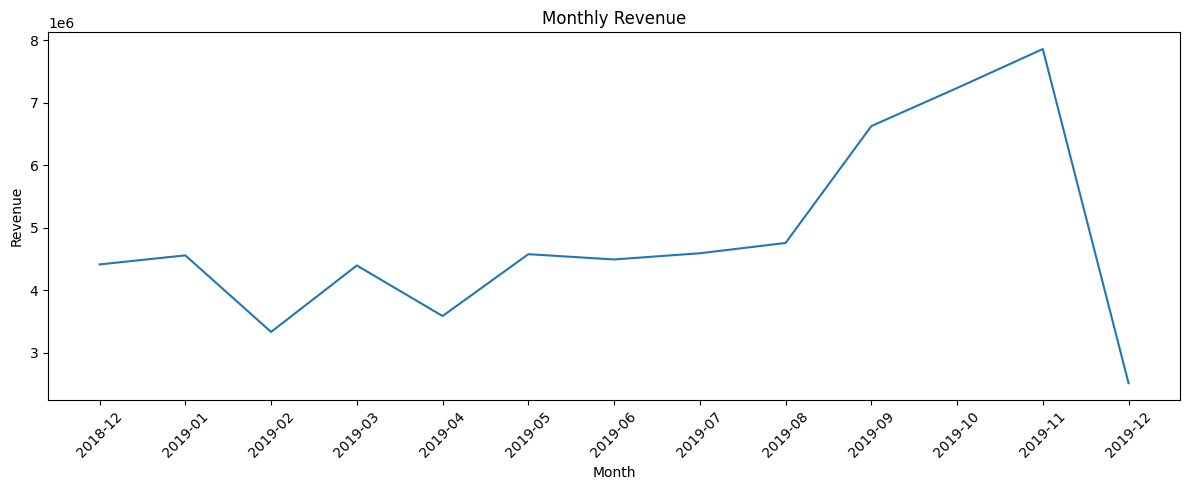

In [19]:
monthly_revenue = df.groupby('YearMonth')['Cost'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['Cost'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


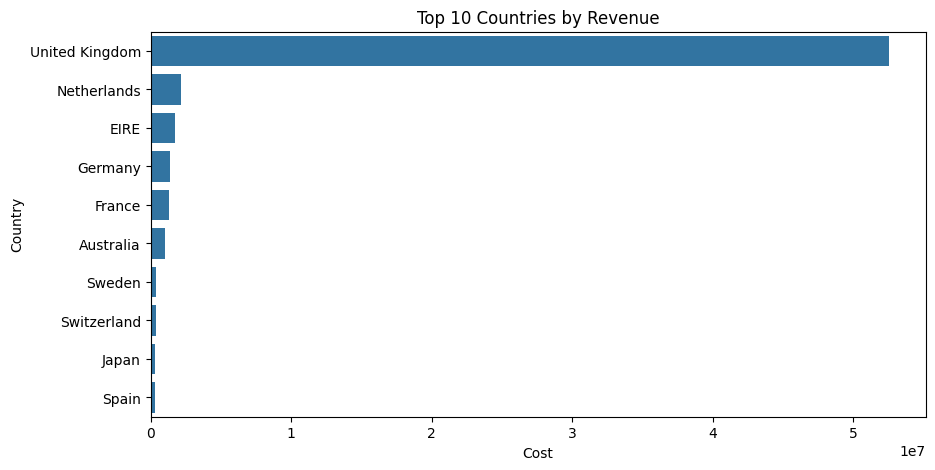

In [20]:
country_revenue = (
    df.groupby('Country')['Cost']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(data=country_revenue, x='Cost', y='Country')
plt.title("Top 10 Countries by Revenue")
plt.show()


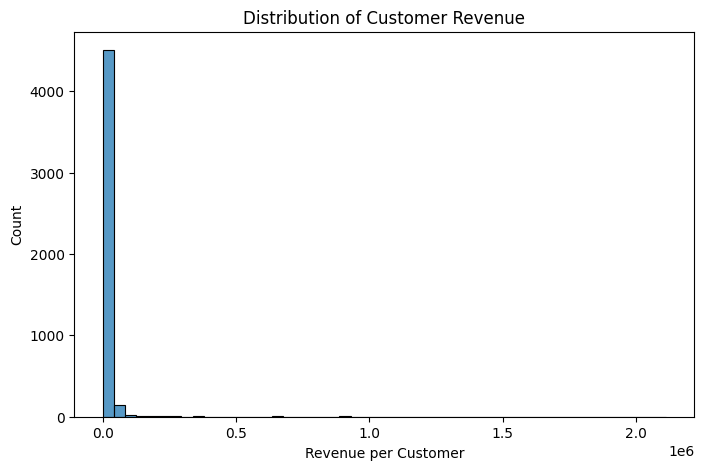

In [21]:
customer_revenue = (
    df.groupby('CustomerNo')['Cost']
      .sum()
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.histplot(customer_revenue['Cost'], bins=50)
plt.title("Distribution of Customer Revenue")
plt.xlabel("Revenue per Customer")
plt.show()


In [22]:
customer_orders = (
    df.groupby('CustomerNo')['TransactionNo']
      .nunique()
      .reset_index(name='NumOrders')
)

repeat_customers = customer_orders['NumOrders'].value_counts()
repeat_customers


NumOrders
1      1577
2       941
3       579
4       433
5       253
6       196
7       154
8       106
9        74
10       59
11       54
12       47
13       31
15       25
14       24
17       19
20       14
16       13
19       12
26       11
18       11
21        9
22        8
28        6
25        5
34        5
31        4
23        4
27        4
39        3
30        3
24        3
37        2
62        2
51        2
44        2
32        2
48        2
46        1
29        1
125       1
36        1
47        1
33        1
91        1
41        1
86        1
198       1
73        1
90        1
55        1
54        1
57        1
38        1
98        1
207       1
60        1
Name: count, dtype: int64

# RFM, K-MEANS, KNN & CLV

## RFM

In [23]:
recency_df = df.groupby('CustomerNo', as_index=False)['Date'].max()
recency_df.columns = ['CustomerNo', 'Last_purchase_date']

max_date = recency_df['Last_purchase_date'].max()

recency_df['Recency'] = recency_df['Last_purchase_date'].apply(
    lambda x: (max_date - x).days
)

recency_df.head()


,CustomerNo,Last_purchase_date,Recency
0,12004.0,2019-04-26,227
1,12006.0,2019-05-05,218
2,12008.0,2019-03-08,276
3,12013.0,2018-12-15,359
4,12024.0,2019-06-16,176


In [24]:
copy_data = df.copy()
copy_data.drop_duplicates(subset=['TransactionNo', 'CustomerNo'], inplace=True)

frequency_df = copy_data.groupby('CustomerNo', as_index=False)['TransactionNo'].count()
frequency_df.columns = ['CustomerNo', 'Frequency']

frequency_df.head()



,CustomerNo,Frequency
0,12004.0,1
1,12006.0,1
2,12008.0,1
3,12013.0,1
4,12024.0,1


In [25]:
monetary_df = df.groupby('CustomerNo', as_index=False)['Cost'].sum()
monetary_df.columns = ['CustomerNo', 'Monetary']

monetary_df.head()

,CustomerNo,Monetary
0,12004.0,1509.60
1,12006.0,24.76
2,12008.0,5689.57
3,12013.0,69.96
4,12024.0,149.52


In [26]:
rfm = recency_df.merge(frequency_df, on='CustomerNo')
rfm = rfm.merge(monetary_df, on='CustomerNo')

rfm.head()


,CustomerNo,Last_purchase_date,Recency,Frequency,Monetary
0,12004.0,2019-04-26,227,1,1509.60
1,12006.0,2019-05-05,218,1,24.76
2,12008.0,2019-03-08,276,1,5689.57
3,12013.0,2018-12-15,359,1,69.96
4,12024.0,2019-06-16,176,1,149.52


In [27]:
rfm['Recency_rank'] = rfm['Recency'].rank(ascending=False)
rfm['Frequency_rank'] = rfm['Frequency'].rank(ascending=True)
rfm['Monetary_rank'] = rfm['Monetary'].rank(ascending=True)

rfm.head()


,CustomerNo,Last_purchase_date,Recency,Frequency,Monetary,Recency_rank,Frequency_rank,Monetary_rank
0,12004.0,2019-04-26,227,1,1509.60,698.0,789.0,955.0
1,12006.0,2019-05-05,218,1,24.76,735.5,789.0,24.5
2,12008.0,2019-03-08,276,1,5689.57,420.0,789.0,2600.0
3,12013.0,2018-12-15,359,1,69.96,102.5,789.0,85.0
4,12024.0,2019-06-16,176,1,149.52,1025.5,789.0,127.0


In [28]:
rfm['Recency_rank_norm'] = (rfm['Recency_rank'] / rfm['Recency_rank'].max()) * 100
rfm['Frequency_rank_norm'] = (rfm['Frequency_rank'] / rfm['Frequency_rank'].max()) * 100
rfm['Monetary_rank_norm'] = (rfm['Monetary_rank'] / rfm['Monetary_rank'].max()) * 100

rfm.head()


,CustomerNo,Last_purchase_date,Recency,Frequency,Monetary,Recency_rank,Frequency_rank,Monetary_rank,Recency_rank_norm,Frequency_rank_norm,Monetary_rank_norm
0,12004.0,2019-04-26,227,1,1509.60,698.0,789.0,955.0,14.852644,16.723188,20.241628
1,12006.0,2019-05-05,218,1,24.76,735.5,789.0,24.5,15.650601,16.723188,0.519288
2,12008.0,2019-03-08,276,1,5689.57,420.0,789.0,2600.0,8.937121,16.723188,55.108097
3,12013.0,2018-12-15,359,1,69.96,102.5,789.0,85.0,2.181083,16.723188,1.801611
4,12024.0,2019-06-16,176,1,149.52,1025.5,789.0,127.0,21.821470,16.723188,2.691819


In [29]:
rfm['RFM_Score'] = (
    0.2 * rfm['Recency_rank_norm'] +
    0.2 * rfm['Frequency_rank_norm'] +
    0.6 * rfm['Monetary_rank_norm']
).round(0)

rfm.head()


,CustomerNo,Last_purchase_date,Recency,Frequency,Monetary,Recency_rank,Frequency_rank,Monetary_rank,Recency_rank_norm,Frequency_rank_norm,Monetary_rank_norm,RFM_Score
0,12004.0,2019-04-26,227,1,1509.60,698.0,789.0,955.0,14.852644,16.723188,20.241628,18.0
1,12006.0,2019-05-05,218,1,24.76,735.5,789.0,24.5,15.650601,16.723188,0.519288,7.0
2,12008.0,2019-03-08,276,1,5689.57,420.0,789.0,2600.0,8.937121,16.723188,55.108097,38.0
3,12013.0,2018-12-15,359,1,69.96,102.5,789.0,85.0,2.181083,16.723188,1.801611,5.0
4,12024.0,2019-06-16,176,1,149.52,1025.5,789.0,127.0,21.821470,16.723188,2.691819,9.0


In [30]:
rfm['Customer_segment'] = np.where(
    rfm['RFM_Score'] < 20, 'Leaving',
    np.where(
        (rfm['RFM_Score'] >= 20) & (rfm['RFM_Score'] < 40), 'Risky Customers',
        np.where(
            rfm['RFM_Score'] < 80, 'Potential Loyalists',
            'Champions'
        )
    )
)

rfm['Customer_segment'].value_counts()


Customer_segment
Potential Loyalists    2174
Risky Customers        1157
Champions               746
Leaving                 641
Name: count, dtype: int64

In [31]:
data_rfm = df.merge(rfm, on='CustomerNo', how='left')


In [32]:
data_rfm.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Cost,YearMonth,...,Frequency,Monetary,Recency_rank,Frequency_rank,Monetary_rank,Recency_rank_norm,Frequency_rank_norm,Monetary_rank_norm,RFM_Score,Customer_segment
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64,2019-12,...,7,13538.07,4699.5,4056.5,3685.0,100.0,85.979228,78.105129,84.0,Champions
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,383.40,2019-12,...,24,63353.94,4699.5,4645.0,4605.0,100.0,98.452734,97.604917,98.0,Champions
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,138.36,2019-12,...,24,63353.94,4699.5,4645.0,4605.0,100.0,98.452734,97.604917,98.0,Champions
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,127.80,2019-12,...,24,63353.94,4699.5,4645.0,4605.0,100.0,98.452734,97.604917,98.0,Champions
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,71.64,2019-12,...,24,63353.94,4699.5,4645.0,4605.0,100.0,98.452734,97.604917,98.0,Champions


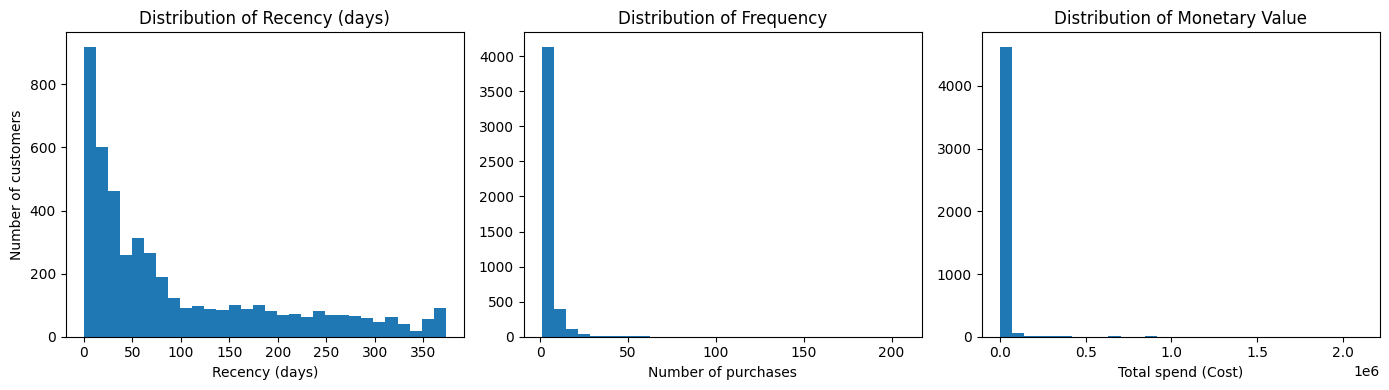

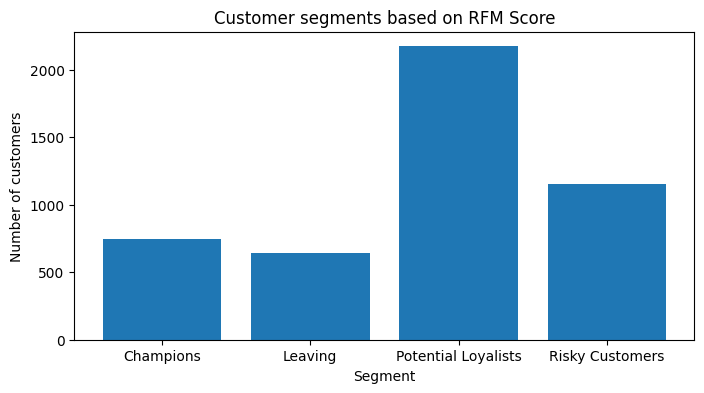

<Figure size 1400x400 with 0 Axes>

In [33]:
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.hist(rfm['Recency'], bins=30)
plt.title('Distribution of Recency (days)')
plt.xlabel('Recency (days)')
plt.ylabel('Number of customers')

plt.subplot(1,3,2)
plt.hist(rfm['Frequency'], bins=30)
plt.title('Distribution of Frequency')
plt.xlabel('Number of purchases')

plt.subplot(1,3,3)
plt.hist(rfm['Monetary'], bins=30)
plt.title('Distribution of Monetary Value')
plt.xlabel('Total spend (Cost)')
plt.tight_layout()
plt.show()

segment_counts = rfm['Customer_segment'].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(segment_counts.index, segment_counts.values)
plt.title('Customer segments based on RFM Score')
plt.xlabel('Segment')
plt.ylabel('Number of customers')
plt.show()

plt.figure(figsize=(14,4))

plt.tight_layout()
plt.show()


## K-Means

In [34]:
features = ['Recency_rank_norm', 'Frequency_rank_norm', 'Monetary_rank_norm']
X = rfm[features].values


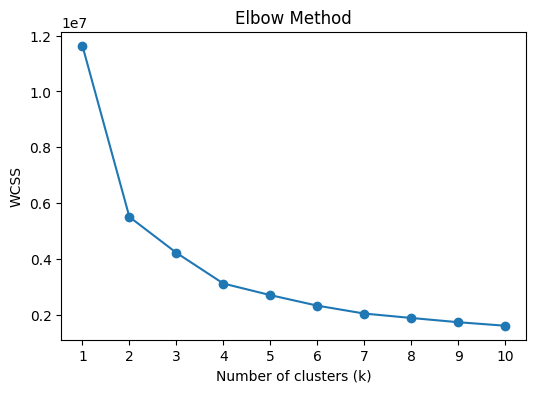

In [35]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.xticks(range(1,11))
plt.show()


In [36]:
sil_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores[k] = score
    print(f"k = {k}, silhouette score = {score:.3f}")


k = 2, silhouette score = 0.434
k = 3, silhouette score = 0.342
k = 4, silhouette score = 0.378
k = 5, silhouette score = 0.342
k = 6, silhouette score = 0.335
k = 7, silhouette score = 0.349
k = 8, silhouette score = 0.333
k = 9, silhouette score = 0.326
k = 10, silhouette score = 0.329


In [37]:
k_optimal = 4

model_kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42)
rfm['cluster'] = model_kmeans.fit_predict(X)

rfm['cluster'].value_counts()


cluster
1    1353
0    1310
3    1113
2     942
Name: count, dtype: int64

In [38]:
cluster_profile = rfm.groupby('cluster')[
    ['Recency', 'Frequency', 'Monetary',
     'Recency_rank_norm', 'Frequency_rank_norm',
     'Monetary_rank_norm', 'RFM_Score']
].mean().round(2)

cluster_profile


,Recency,Frequency,Monetary,Recency_rank_norm,Frequency_rank_norm,Monetary_rank_norm,RFM_Score
cluster,,,,,,,
0,16.82,9.81,34355.03,79.02,83.26,80.63,80.84
1,209.29,1.21,1847.84,19.31,22.01,22.14,21.55
2,25.03,1.93,2762.56,70.98,37.69,31.05,40.37
3,111.51,3.13,11552.88,36.27,55.34,63.90,56.67


In [39]:
pd.crosstab(rfm['cluster'], rfm['Customer_segment'])


Customer_segment,Champions,Leaving,Potential Loyalists,Risky Customers
cluster,,,,
0,737,0,573,0
1,0,622,61,670
2,0,19,486,437
3,9,0,1054,50


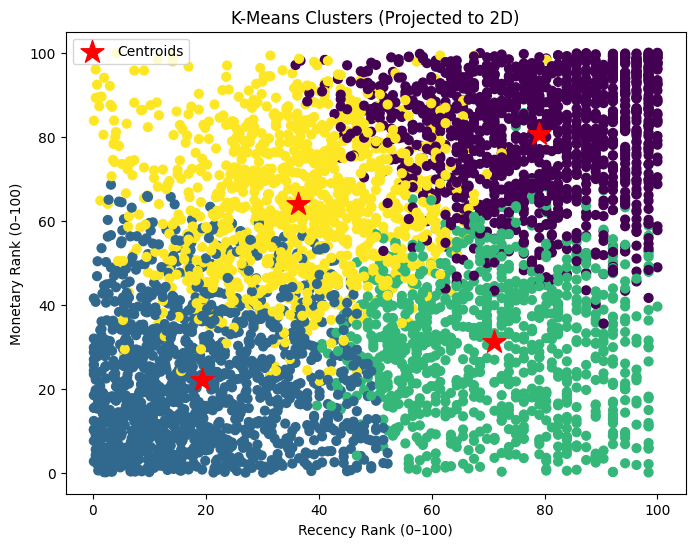

In [40]:
data_features = rfm[['Recency_rank_norm', 'Monetary_rank_norm']].values
labels = rfm['cluster']

centers = model_kmeans.cluster_centers_[:, [0, 2]]

plt.figure(figsize=(8,6))
plt.scatter(data_features[:,0], data_features[:,1], c=labels, s=40, cmap='viridis')
plt.scatter(centers[:,0], centers[:,1], s=300, c='red', marker='*', label='Centroids')

plt.xlabel("Recency Rank (0–100)")
plt.ylabel("Monetary Rank (0–100)")
plt.title("K-Means Clusters (Projected to 2D)")
plt.legend()
plt.show()


In [41]:
cluster_counts = rfm['cluster'].value_counts().sort_index()
cluster_revenue = rfm.groupby('cluster')['Monetary'].sum()
cluster_revenue_share = (cluster_revenue / cluster_revenue.sum() * 100).round(1)

cluster_profile['n_customers'] = cluster_counts
cluster_profile['revenue_total'] = cluster_revenue.round(2)
cluster_profile['revenue_share_%'] = cluster_revenue_share

cluster_profile


,Recency,Frequency,Monetary,Recency_rank_norm,Frequency_rank_norm,Monetary_rank_norm,RFM_Score,n_customers,revenue_total,revenue_share_%
cluster,,,,,,,,,,
0,16.82,9.81,34355.03,79.02,83.26,80.63,80.84,1310,45005085.12,71.5
1,209.29,1.21,1847.84,19.31,22.01,22.14,21.55,1353,2500129.60,4.0
2,25.03,1.93,2762.56,70.98,37.69,31.05,40.37,942,2602327.69,4.1
3,111.51,3.13,11552.88,36.27,55.34,63.90,56.67,1113,12858349.93,20.4


In [42]:
good_clusters = [0, 3]

base_revenue_good = rfm.loc[rfm['cluster'].isin(good_clusters), 'Monetary'].sum()

lift = 0.05
extra_revenue = base_revenue_good * lift
new_revenue_good = base_revenue_good * (1 + lift)

base_revenue_good, extra_revenue, new_revenue_good


(np.float64(57863435.050000004),
 np.float64(2893171.7525000004),
 np.float64(60756606.80250001))

## KNN

In [43]:
X = rfm[['Recency_rank_norm', 'Frequency_rank_norm', 'Monetary_rank_norm']]
y = rfm['cluster']  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)



In [44]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [46]:
y_pred = knn.predict(X_test)

In [47]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred, average='macro'))


Confusion Matrix:
[[260   0   1   1]
 [  0 267   2   2]
 [  0   6 182   0]
 [  2   2   0 219]]

Accuracy: 0.9830508474576272
Precision: 0.9833864433482754
Recall: 0.9819385378160753
F1 Score: 0.9826323417074972


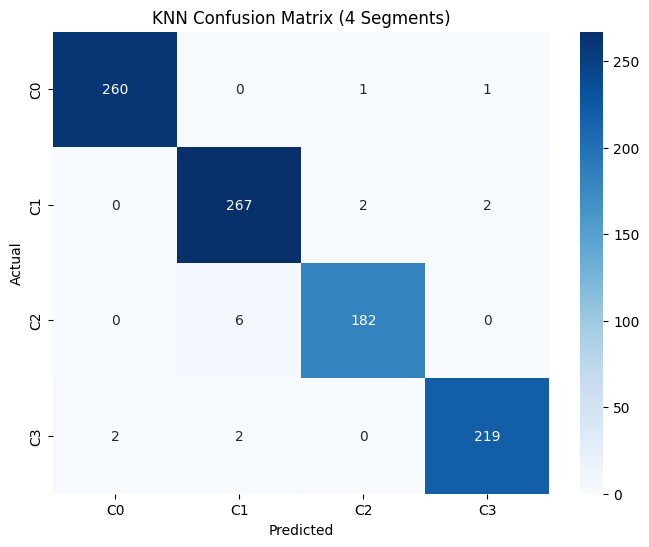

In [49]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['C0','C1','C2','C3'],
            yticklabels=['C0','C1','C2','C3'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix (4 Segments)")
plt.show()

## CLV

In [50]:
clv_data = data_rfm.copy()

clv_data = clv_data[clv_data['Quantity'] > 0]

clv_data['Cost'] = clv_data['Price'] * clv_data['Quantity']

prep_clv = clv_data.groupby('CustomerNo').agg(
    total_transaction=('TransactionNo', 'nunique'),
    total_unit=('Quantity', 'sum'),                   
    total_price=('Cost', 'sum')                       
)

prep_clv.head()


,total_transaction,total_unit,total_price
CustomerNo,,,
12004.0,1,104,1509.60
12006.0,1,2,24.76
12008.0,1,421,5689.57
12013.0,1,3,69.96
12024.0,1,14,149.52


In [51]:
prep_clv['average_order_value'] = prep_clv['total_price'] / prep_clv['total_transaction']

purchase_frequency = prep_clv['total_transaction'].sum() / prep_clv.shape[0]

repeat_rate = prep_clv[prep_clv['total_transaction'] > 1].shape[0] / prep_clv.shape[0]
churn_rate = 1 - repeat_rate

print("Purchase frequency:", purchase_frequency)
print("Repeat rate:", repeat_rate)
print("Churn rate:", churn_rate)


Purchase frequency: 4.1943620178041545
Repeat rate: 0.6657481983891479
Churn rate: 0.3342518016108521


In [52]:
profit_margin_rate = 0.10

prep_clv['profit_margin'] = profit_margin_rate

prep_clv['purchase_frequency'] = purchase_frequency  
prep_clv['customer_value'] = prep_clv['average_order_value'] * prep_clv['purchase_frequency']

prep_clv['clv'] = (prep_clv['customer_value'] / churn_rate) * prep_clv['profit_margin']

prep_clv.head()


,total_transaction,total_unit,total_price,average_order_value,profit_margin,purchase_frequency,customer_value,clv
CustomerNo,,,,,,,,
12004.0,1,104,1509.60,1509.60,0.1,4.194362,6331.808902,1894.323044
12006.0,1,2,24.76,24.76,0.1,4.194362,103.852404,31.070110
12008.0,1,421,5689.57,5689.57,0.1,4.194362,23864.116306,7139.562507
12013.0,1,3,69.96,69.96,0.1,4.194362,293.437567,87.789375
12024.0,1,14,149.52,149.52,0.1,4.194362,627.141009,187.625319


In [53]:
prep_clv['segment'] = pd.qcut(prep_clv['clv'], 4, labels=['D', 'C', 'B', 'A'])

segment_summary = prep_clv.groupby('segment').agg(['count', 'mean', 'sum'])
segment_summary


/var/folders/tr/f5rhth956sl3c85kyq82lx3r0000gn/T/ipykernel_27196/4007468165.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = prep_clv.groupby('segment').agg(['count', 'mean', 'sum'])


total_transaction                 total_unit                        \
                    count      mean   sum      count         mean      sum   
segment                                                                      
D                    1180  2.806780  3312       1180   164.017797   193541   
C                    1179  4.362171  5143       1179   552.156064   650992   
B                    1179  4.966921  5856       1179  1094.438507  1290343   
A                    1180  4.642373  5478       1180  2929.333898  3456614   

        total_price                            average_order_value  ...  \
              count          mean          sum               count  ...   
segment                                                             ...   
D              1180   1897.758364   2239354.87                1180  ...   
C              1179   6259.775064   7380274.80                1179  ...   
B              1179  12248.223537  14440655.55                1179  ...   
A              1180  32970.853492  38905607.12                1180  ...   

        profit_margin purchase_frequency                         \
                  sum              count      mean          sum   
segment                                                           
D               118.0               1180  4.194362  4949.347181   
C               117.9               1179  4.194362  4945.152819   
B               117.9               1179  4.194362  4945.152819   
A               118.0               1180  4.194362  4949.347181   

        customer_value                               clv               \
                 count          mean           sum count         mean   
segment                                                                 
D                 1180   2552.525081  3.011980e+06  1180   763.653350   
C                 1179   6029.858705  7.109203e+06  1179  1803.986897   
B                 1179  10330.322636  1.217945e+07  1179  3090.580989   
A                 1180  33322.460125  3.932050e+07  1180  9969.268666   

                       
                  sum  
segment                
D        9.011110e+05  
C        2.126901e+06  
B        3.643795e+06  
A        1.176374e+07  

[4 rows x 24 columns]

In [54]:
prep_clv['segment'] = pd.qcut(prep_clv['clv'], 4, labels=['D', 'C', 'B', 'A'])

segment_summary = prep_clv.groupby('segment').agg(['count', 'mean', 'sum'])
segment_summary


/var/folders/tr/f5rhth956sl3c85kyq82lx3r0000gn/T/ipykernel_27196/4007468165.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = prep_clv.groupby('segment').agg(['count', 'mean', 'sum'])


total_transaction                 total_unit                        \
                    count      mean   sum      count         mean      sum   
segment                                                                      
D                    1180  2.806780  3312       1180   164.017797   193541   
C                    1179  4.362171  5143       1179   552.156064   650992   
B                    1179  4.966921  5856       1179  1094.438507  1290343   
A                    1180  4.642373  5478       1180  2929.333898  3456614   

        total_price                            average_order_value  ...  \
              count          mean          sum               count  ...   
segment                                                             ...   
D              1180   1897.758364   2239354.87                1180  ...   
C              1179   6259.775064   7380274.80                1179  ...   
B              1179  12248.223537  14440655.55                1179  ...   
A              1180  32970.853492  38905607.12                1180  ...   

        profit_margin purchase_frequency                         \
                  sum              count      mean          sum   
segment                                                           
D               118.0               1180  4.194362  4949.347181   
C               117.9               1179  4.194362  4945.152819   
B               117.9               1179  4.194362  4945.152819   
A               118.0               1180  4.194362  4949.347181   

        customer_value                               clv               \
                 count          mean           sum count         mean   
segment                                                                 
D                 1180   2552.525081  3.011980e+06  1180   763.653350   
C                 1179   6029.858705  7.109203e+06  1179  1803.986897   
B                 1179  10330.322636  1.217945e+07  1179  3090.580989   
A                 1180  33322.460125  3.932050e+07  1180  9969.268666   

                       
                  sum  
segment                
D        9.011110e+05  
C        2.126901e+06  
B        3.643795e+06  
A        1.176374e+07  

[4 rows x 24 columns]

/var/folders/tr/f5rhth956sl3c85kyq82lx3r0000gn/T/ipykernel_27196/3938162198.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv_by_segment = prep_clv.groupby('segment')['clv'].mean()


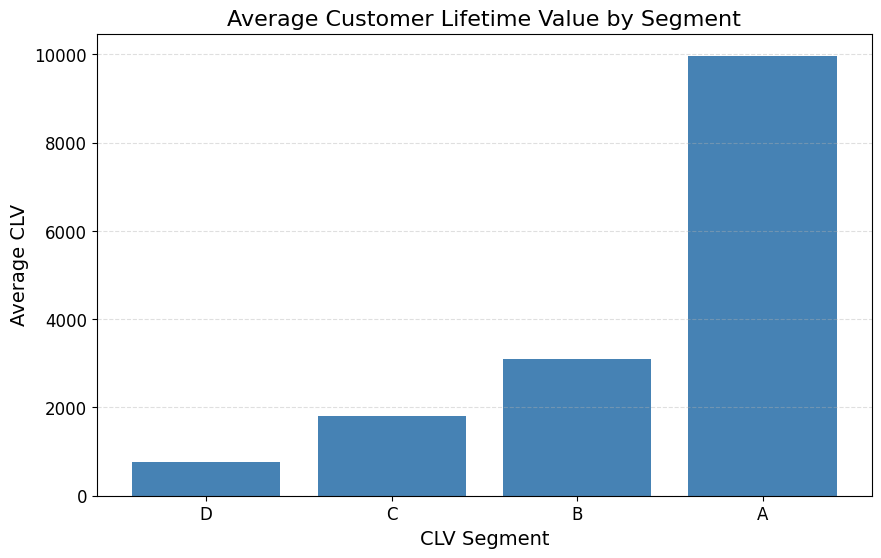

In [55]:
avg_clv_by_segment = prep_clv.groupby('segment')['clv'].mean()

plt.figure(figsize=(10,6))
plt.bar(avg_clv_by_segment.index, avg_clv_by_segment.values, color='steelblue')

plt.title("Average Customer Lifetime Value by Segment", fontsize=16)
plt.xlabel("CLV Segment", fontsize=14)
plt.ylabel("Average CLV", fontsize=14)

plt.xticks(rotation=0, fontsize=12) 
plt.yticks(fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


# Linear Regression

In [56]:
clv_for_model = prep_clv[['clv']].reset_index()   

rfm_clv = rfm.merge(clv_for_model, on='CustomerNo', how='inner')

rfm_clv.head()


,CustomerNo,Last_purchase_date,Recency,Frequency,Monetary,Recency_rank,Frequency_rank,Monetary_rank,Recency_rank_norm,Frequency_rank_norm,Monetary_rank_norm,RFM_Score,Customer_segment,cluster,clv
0,12004.0,2019-04-26,227,1,1509.60,698.0,789.0,955.0,14.852644,16.723188,20.241628,18.0,Leaving,1,1894.323044
1,12006.0,2019-05-05,218,1,24.76,735.5,789.0,24.5,15.650601,16.723188,0.519288,7.0,Leaving,1,31.070110
2,12008.0,2019-03-08,276,1,5689.57,420.0,789.0,2600.0,8.937121,16.723188,55.108097,38.0,Risky Customers,1,7139.562507
3,12013.0,2018-12-15,359,1,69.96,102.5,789.0,85.0,2.181083,16.723188,1.801611,5.0,Leaving,1,87.789375
4,12024.0,2019-06-16,176,1,149.52,1025.5,789.0,127.0,21.821470,16.723188,2.691819,9.0,Leaving,1,187.625319


In [57]:
feature_cols = ['Recency', 'Frequency', 'Monetary'] 
X = rfm_clv[feature_cols]
y = rfm_clv['clv']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 3470.161176988359
RMSE: 32364.2065598302
R²  : 0.17296093340071106


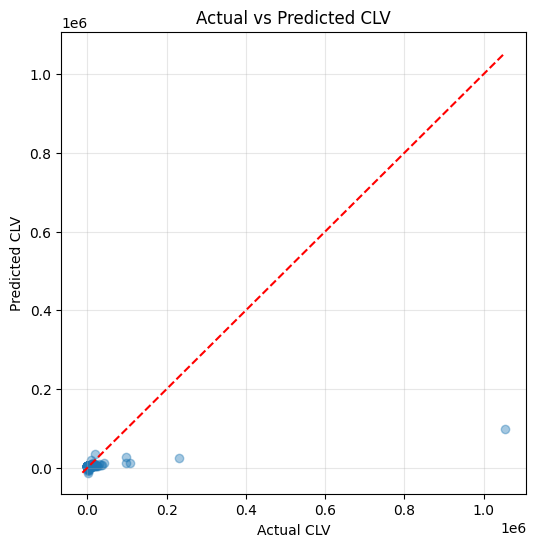

In [58]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel('Actual CLV')
plt.ylabel('Predicted CLV')
plt.title('Actual vs Predicted CLV')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.grid(True, alpha=0.3)
plt.show()


## Logistic Regression

In [59]:
rfm['high_value'] = rfm['cluster'].isin([0, 3]).astype(int)

rfm['high_value'].value_counts()


high_value
1    2423
0    2295
Name: count, dtype: int64

In [60]:
X = rfm[['Recency_rank_norm', 'Frequency_rank_norm', 'Monetary_rank_norm']]

y = rfm['high_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [61]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]


ROC AUC: 0.9939941154010287


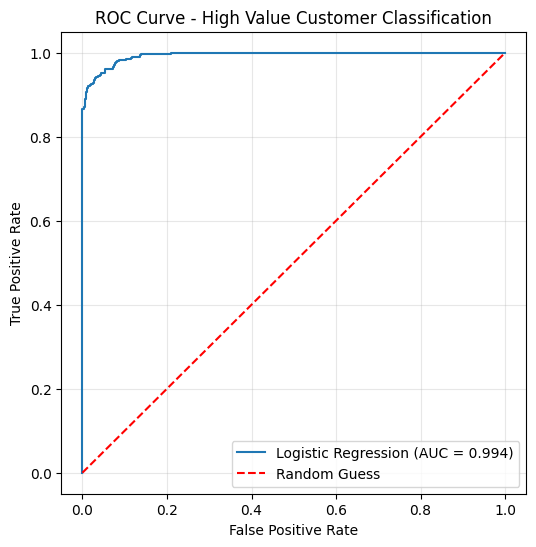

In [62]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

auc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", auc)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'r--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - High Value Customer Classification")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [63]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (high value class):", precision_score(y_test, y_pred))
print("Recall (high value class):", recall_score(y_test, y_pred))
print("F1 Score (high value class):", f1_score(y_test, y_pred))


Accuracy: 0.951271186440678
Precision (high value class): 0.9582463465553236
Recall (high value class): 0.9463917525773196
F1 Score (high value class): 0.9522821576763485


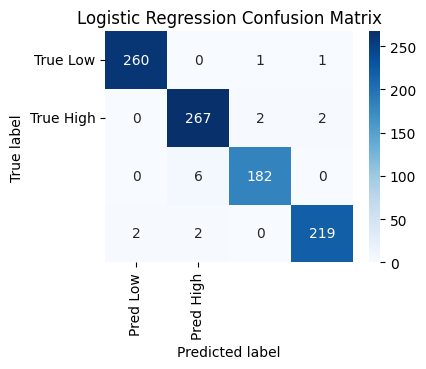

In [64]:
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Low', 'Pred High'],
            yticklabels=['True Low', 'True High'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


# A/B Testing

In [65]:
np.random.seed(123)


In [66]:
p_control = 0.12       
lift = 0.05            
p_treat = p_control * (1 + lift)   
alpha = 0.05         
power = 0.80           

print("Control conversion (p1):", p_control)
print("Treatment conversion if effect exists (p2):", p_treat)

cohen_h = sm.stats.proportion_effectsize(p_control, p_treat)
print("Cohen's h:", round(cohen_h, 4))

ttest_power = TTestIndPower()
n_raw = ttest_power.solve_power(effect_size=cohen_h, power=power, alpha=alpha)
n_per_group = int(round(n_raw, -2))         

print(f"\nTo detect a {lift*100:.1f}% lift from {p_control*100:.1f}% baseline with "
      f"{power*100:.0f}% power at α={alpha}:")
print("Sample size per group required:", n_per_group)
print("Total sample size required:", 2 * n_per_group)


Control conversion (p1): 0.12
Treatment conversion if effect exists (p2): 0.126
Cohen's h: -0.0183

To detect a 5.0% lift from 12.0% baseline with 80% power at α=0.05:
Sample size per group required: 47000
Total sample size required: 94000


In [67]:
n = n_per_group

control_outcomes = np.random.binomial(1, p_control, n)
treat_outcomes   = np.random.binomial(1, p_treat, n)

AB_control_cnt  = control_outcomes.sum()
AB_treatment_cnt = treat_outcomes.sum()

AB_control_size = n
AB_treatment_size = n

AB_control_rate  = AB_control_cnt / AB_control_size
AB_treatment_rate = AB_treatment_cnt / AB_treatment_size

print("Control sign-up count:", AB_control_cnt)
print("Treatment sign-up count:", AB_treatment_cnt)
print("Control conversion rate:", round(AB_control_rate, 4))
print("Treatment conversion rate:", round(AB_treatment_rate, 4))


Control sign-up count: 5567
Treatment sign-up count: 5879
Control conversion rate: 0.1184
Treatment conversion rate: 0.1251


In [68]:
AB_ALPHA = 0.05

AB_chistats, AB_pvalue_chi, AB_tab = proportions_chisquare(
    [AB_control_cnt, AB_treatment_cnt],
    nobs=[AB_control_size, AB_treatment_size]
)

print("-------- AB Test: Personalized vs Generic Offer --------\n")
print("H0: Conversion rates between generic and personalized offer are the same.")
print("Ha: Conversion rates between generic and personalized offer are different.\n")
print(f"Significance level: {AB_ALPHA}")
print(f"Chi-Square = {AB_chistats:.3f} | P-value = {AB_pvalue_chi:.3f}")

print("\nConclusion (Chi-Square):")
if AB_pvalue_chi < AB_ALPHA:
    print("Reject H0 → There is statistical evidence that conversion rates differ.")
else:
    print("Fail to reject H0 → No statistical evidence of a difference.")


-------- AB Test: Personalized vs Generic Offer --------

H0: Conversion rates between generic and personalized offer are the same.
Ha: Conversion rates between generic and personalized offer are different.

Significance level: 0.05
Chi-Square = 9.684 | P-value = 0.002

Conclusion (Chi-Square):
Reject H0 → There is statistical evidence that conversion rates differ.


In [69]:
AB_tstat, AB_pvalue_ttest = ttest_ind(
    treat_outcomes,
    control_outcomes,
    equal_var=False
)

print("\n-------- T-Test on Conversion (0/1 Data) --------\n")
print("H0: Mean conversion (generic) = mean conversion (personalized).")
print("Ha: Mean conversion is different.\n")

print(f"Significance level: {AB_ALPHA}")
print(f"T-Statistic = {AB_tstat:.3f} | P-value = {AB_pvalue_ttest:.3f}")

print("\nConclusion (T-Test):")
if AB_pvalue_ttest < AB_ALPHA:
    print("Reject H0 → The personalized offer significantly changes conversion.")
else:
    print("Fail to reject H0 → No significant effect detected.")



-------- T-Test on Conversion (0/1 Data) --------

H0: Mean conversion (generic) = mean conversion (personalized).
Ha: Mean conversion is different.

Significance level: 0.05
T-Statistic = 3.112 | P-value = 0.002

Conclusion (T-Test):
Reject H0 → The personalized offer significantly changes conversion.


In [70]:
ci = confint_proportions_2indep(
    AB_treatment_cnt,
    AB_treatment_size,
    AB_control_cnt,
    AB_control_size,
    method=None,
    compare='diff',
    alpha=AB_ALPHA,
    correction=True
)

lower_diff, upper_diff = ci
lower_lift = lower_diff / AB_control_rate
upper_lift = upper_diff / AB_control_rate

print("\n---------- Sample Sizes ----------")
print(f"Control:   {AB_control_size}")
print(f"Treatment: {AB_treatment_size}")

print("\n---------- Conversion Counts (Rates) ----------")
print(f"Control:   {AB_control_cnt} ({AB_control_rate*100:.1f}%)")
print(f"Treatment: {AB_treatment_cnt} ({AB_treatment_rate*100:.1f}%)")

abs_diff = AB_treatment_rate - AB_control_rate
rel_lift = abs_diff / AB_control_rate

print("\n---------- Differences ----------")
print(f"Absolute difference: {abs_diff:.4f}")
print(f"Relative lift: {rel_lift*100:.1f}%")

print("\n---------- T-Stats ----------")
print(f"T-Statistic: {AB_tstat:.3f}")
print(f"P-Value: {AB_pvalue_ttest:.5f}")

print("\n---------- Confidence Intervals ----------")
print(f"Absolute difference CI: ({lower_diff:.3f}, {upper_diff:.3f})")
print(f"Relative lift CI: ({lower_lift*100:.1f}%, {upper_lift*100:.1f}%)")



---------- Sample Sizes ----------
Control:   47000
Treatment: 47000

---------- Conversion Counts (Rates) ----------
Control:   5567 (11.8%)
Treatment: 5879 (12.5%)

---------- Differences ----------
Absolute difference: 0.0066
Relative lift: 5.6%

---------- T-Stats ----------
T-Statistic: 3.112
P-Value: 0.00186

---------- Confidence Intervals ----------
Absolute difference CI: (0.002, 0.011)
Relative lift CI: (2.1%, 9.1%)
